## **Tugas 1 Individu PBA Genap 2026 - Netflix Sentiment Analysis**
#### Oryza Reynaleta Wibowo - 5026231081

## **1. Install & Import Library**


In [81]:
# Install library yang dibutuhkan
!pip install google-play-scraper
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install wordcloud

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Library untuk Scraping
from google_play_scraper import reviews, Sort

# Library untuk NLP & Preprocessing (English)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Library untuk Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

# Download dependency NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### **2. Data Collection & Scrapping**

In [82]:
print("Data scrapping on progress...")
result, _ = reviews(
    'com.netflix.mediaclient',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=100000
)

print(f"Successfully scrapped {len(result)} reviews")

Data scrapping on progress...
Successfully scrapped 100000 reviews


In [83]:
# Konversi ke DataFrame
df_netflix = pd.DataFrame(result)
df_netflix.drop_duplicates(subset=['content'], inplace=True)

df_column = [
    'reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
    'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion'
]
df_netflix = df_netflix[df_column]

display(df_netflix.head())

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9ef5a262-b8cd-4f57-b100-add0c720acd4,A Google user,so far so good this app is support for my work...,5,0,9.55.0 build 6 63912,2026-03-02 12:48:24,None,None,9.55.0 build 6 63912
1,68effe57-f525-45d7-aaa4-da365275175e,A Google user,Impressive performance.,5,0,9.55.0 build 6 63912,2026-03-02 12:34:28,None,None,9.55.0 build 6 63912
2,5adc36c7-45aa-4730-b311-79ddd2a022da,A Google user,good,4,0,None,2026-03-02 12:27:41,None,None,None
3,3f5bffa4-6d1d-4f69-b7e2-ee9963a291ea,A Google user,one star only because it now just doesn't let ...,1,0,8.107.0 build 9 50640,2026-03-02 11:52:32,None,None,8.107.0 build 9 50640
4,50080e9e-8203-4dcd-9799-27ac80a7441a,A Google user,😅,5,0,None,2026-03-02 11:45:41,None,None,None


In [84]:
# Export data ke CSV
df_netflix.to_csv('netflix_reviews_raw.csv', index=False)
print("\nSuccessfully exported raw data on 'netflix_reviews_raw.csv'")


Successfully exported raw data on 'netflix_reviews_raw.csv'


### **3. Data Cleaning**
Normalisasi, Cleaning, & Lemmatization

In [85]:
# 1. Normalisasi Slang/Singkatan
normalization_dict = {
    "ap" : "application", "app": "application", "apk": "application", "ui": "user interface",
    "ux": "user experience", "vid": "video", "vids": "videos",
    "ep": "episode", "eps": "episodes", "szn": "season",
    "sub": "subscription", "subs": "subscription", "dub": "dubbing",
    "dubs": "dubbing", "dl": "download", "acc": "account",
    "acct": "account", "pw": "password", "pass": "password",
    "recs": "recommendations", "tv": "television", "pic": "picture",
    "u": "you", "ur": "your", "urs": "yours", "r": "are", "c": "see",
    "y": "why", "pls": "please", "plz": "please", "thx": "thanks",
    "ty": "thank you", "omg": "oh my god", "idk": "i do not know",
    "idc": "i do not care", "imo": "in my opinion", "imho": "in my humble opinion",
    "rn": "right now", "fr": "for real", "tbh": "to be honest",
    "ngl": "not going to lie", "btw": "by the way", "fyi": "for your information",
    "bc": "because", "cuz": "because", "cos": "because", "cause": "because",
    "k": "okay", "ok": "okay", "smh": "shaking my head", "lmao": "laughing",
    "lmfao": "laughing", "lol": "laugh out loud", "af": "as fuck",
    "asap": "as soon as possible", "nvm": "nevermind", "np": "no problem",
    "ofc": "of course", "ppl": "people", "kinda": "kind of", "sorta": "sort of",
    "gonna": "going to", "wanna": "want to", "gotta": "got to",
    "lemme": "let me", "gimme": "give me", "tho": "though", "b4": "before",
    "gr8": "great", "l8r": "later", "msg": "message", "txt": "text", "pls": "please",
    "im": "i am", "dont": "do not", "cant": "cannot", "wont": "will not",
    "didnt": "did not", "doesnt": "does not", "isnt": "is not",
    "arent": "are not", "wasnt": "was not", "werent": "were not",
    "hasnt": "has not", "havent": "have not", "hadnt": "had not",
    "couldnt": "could not", "shouldnt": "should not", "wouldnt": "would not",
    "ive": "i have", "youve": "you have", "weve": "we have",
    "theyve": "they have", "thats": "that is", "theres": "there is",
    "ill": "i will", "youll": "you will", "itll": "it will", "hes": "he is",
    "shes": "she is", "lets": "let us", "id": "i would", "youd": "you would",
    "till": "until", "til": "until", "bout": "about", "somethin": "something",
    "nothin": "nothing"
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_normalize(text):
    # Lowercase
    text = str(text).lower()

    # Normalisasi huruf yang diulang berlebihan
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Hapus URL, angka, dan karakter khusus
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Tokenisasi
    tokens = word_tokenize(text)

    # Stopword Removal, Normalisasi Kamus, & Lemmatization
    cleaned_tokens = []
    for word in tokens:
        # Terapkan normalisasi jika kata ada di kamus
        word_norm = normalization_dict.get(word, word)

        # Lemmatize dan hapus stopwords
        if word_norm not in stop_words and len(word_norm) > 1:
            lemmatized_word = lemmatizer.lemmatize(word_norm)
            cleaned_tokens.append(lemmatized_word)

    return " ".join(cleaned_tokens)

df_netflix['clean_content'] = df_netflix['content'].apply(clean_and_normalize)
df_clean = df_netflix[df_netflix['clean_content'].str.strip() != '']

print("Cleaned Content Comparison")
display(df_clean[['userName', 'content', 'clean_content']].head())

Cleaned Content Comparison


,userName,content,clean_content
0,A Google user,so far so good this app is support for my work...,far good application support workand applicati...
1,A Google user,Impressive performance.,impressive performance
2,A Google user,good,good
3,A Google user,one star only because it now just doesn't let ...,one star does not let look television show mov...
5,A Google user,cool ap,cool application


### **4. Score Distributions Visualization**

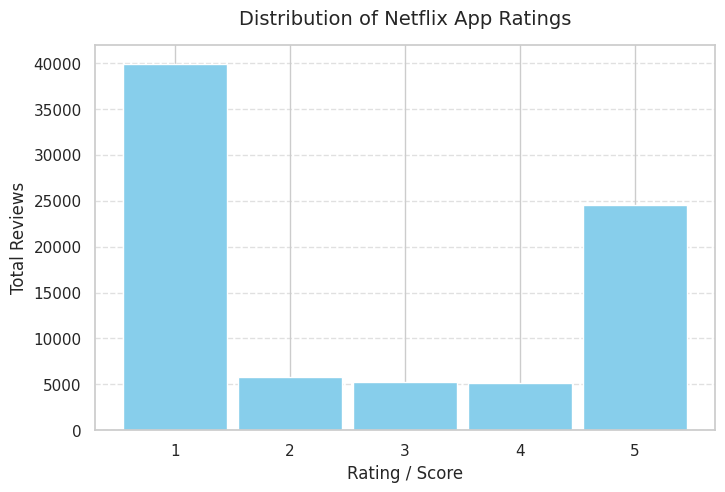

In [86]:
rating_counts = df_netflix['score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    rating_counts.index,
    rating_counts.values,
    color='skyblue',
    width=0.9
)

plt.title('Distribution of Netflix App Ratings', fontsize=14, pad=15)
plt.xlabel('Rating / Score', fontsize=12)
plt.ylabel('Total Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [87]:
# Export data ke CSV
df_clean.to_csv('netflix_reviews_clean.csv', index=False)
print("\nSuccessfully exported raw data on 'netflix_reviews_clean.csv'")


Successfully exported raw data on 'netflix_reviews_clean.csv'


### **5. Word Frequency Analysis**

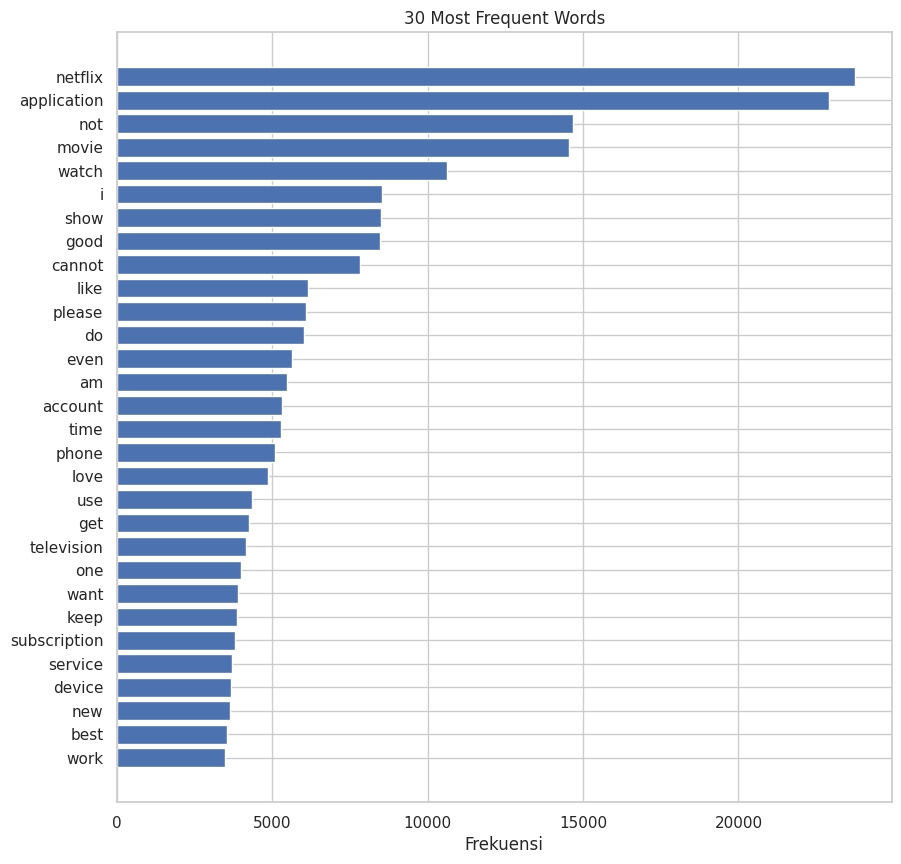

In [88]:
all_words = []
for text in df_clean['clean_content']:
    all_words.extend(text.split())

word_counts = Counter(all_words).most_common(30)
words, counts = zip(*word_counts)

# Plot frekuensi kata
plt.figure(figsize=(10, 10))
plt.barh(words, counts)
plt.title("30 Most Frequent Words")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.show()

### **6. Wordcloud Visualization**

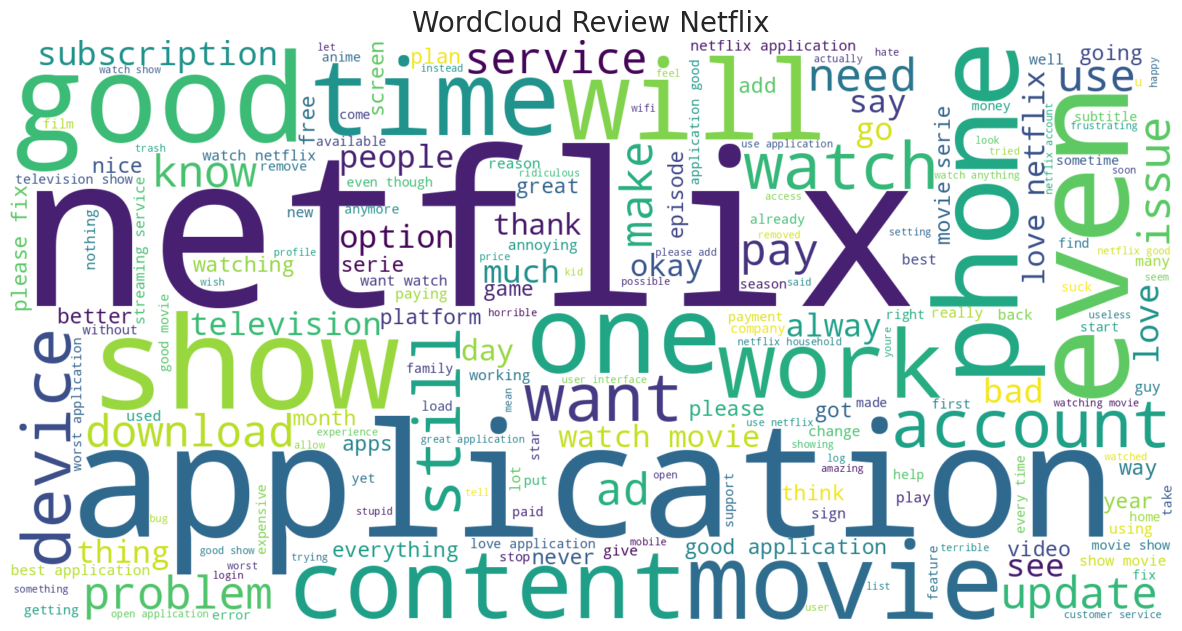

In [89]:
text_corpus = " ".join(df_clean['clean_content'].tolist())
wordcloud = WordCloud(
    width=1600, height=800, background_color='white', colormap='viridis', max_words=200
).generate(text_corpus)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Review Netflix", fontsize=20)
plt.show()

## **7. The N-Gram Analysis**


In [90]:
corpus = df_clean['clean_content'].tolist()

def get_top_ngrams(corpus, ngram_range=(2,2), top_k=20):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Bigram
top_bigrams = get_top_ngrams(corpus, ngram_range=(2,2), top_k=20)
print("Top 20 Bigrams (2 Words Combo):")
for word, freq in top_bigrams:
    print(f"{word}: {freq}")

print("\n--------------------------\n")

# Trigram
top_trigrams = get_top_ngrams(corpus, ngram_range=(3,3), top_k=20)
print("Top 20 Trigrams (3Words Combo):")
for word, freq in top_trigrams:
    print(f"{word}: {freq}")

Top 20 Bigrams (2 Words Combo):
do not: 6020
does not: 2950
will not: 1790
cannot watch: 1147
watch movie: 1098
cannot even: 1028
love netflix: 1008
good application: 1004
not work: 993
is not: 977
please fix: 960
that is: 944
there is: 941
movie series: 931
did not: 928
not know: 842
show movie: 841
streaming service: 830
watch netflix: 762
best application: 760

--------------------------

Top 20 Trigrams (3Words Combo):
do not know: 805
does not work: 681
do not want: 492
do not like: 441
will not let: 434
application does not: 358
movie television show: 317
cannot even watch: 261
do not even: 231
as soon as: 225
soon as possible: 225
netflix do not: 214
is not part: 198
do not use: 197
device is not: 190
application do not: 189
part netflix household: 184
do not get: 180
worst application ever: 175
please do not: 175


### **8. Sentiment Analysis**

In [91]:
from textblob import TextBlob

# Execute TextBlob polarity and subjectivity calculations against string-converted content
df_clean['sentiment_polarity'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_clean['sentiment_subjective'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

# Select Sample Groups
# Sample 50 Positive Reviews (> 0 Polarity)
df_positive = df_clean[df_clean['sentiment_polarity'] > 0].sample(n=50, random_state=42)

# Select ALL Negative Reviews (< 0 Polarity)
df_negative = df_clean[df_clean['sentiment_polarity'] < 0]

# Merge the subsets
df_sampled = pd.concat([df_positive, df_negative])

# Isolate the requested return columns
df_sampled = df_sampled.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective"]]

print(f"Sampled group consists of {len(df_sampled)} total reviews.")
display(df_sampled.head(10))

/tmp/ipykernel_249/2708673535.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sentiment_polarity'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).polarity)


Sampled group consists of 18763 total reviews.


/tmp/ipykernel_249/2708673535.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sentiment_subjective'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)


,content,score,sentiment_polarity,sentiment_subjective
13990,good purfekt,5,0.700000,0.600000
26795,supposed to be 5 but -1 because of the Kpop de...,4,0.550000,0.800000
33748,They have no interest in providing anyone with...,1,0.115873,0.590476
87959,Watch it every day love the shows love the mov...,5,0.300000,0.480000
19418,this app is really great for all users but one...,5,0.800000,0.750000
90229,Netflix uses dark patterns in their UI. Inexcu...,1,0.054762,0.475397
25744,Best app it runs smoothly.,4,0.700000,0.400000
25741,nice display,5,0.600000,1.000000
2905,"more then 30% moves doesn't even exist, not ev...",3,0.333333,0.333333
27841,an amazing experience with this app,5,0.600000,0.900000


#### **Sentiment Classification Pipeline**

In [92]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Execute TextBlob polarity calculation against string-converted content
df_clean['sentiment_polarity'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).polarity)

# Binarisasi Pelabelan Sentimen (TextBlob: >0=Positif, <0=Negatif, 0=Netral dibuang)
df_clean = df_clean[df_clean['sentiment_polarity'] != 0.0].copy()
df_clean['sentiment'] = np.where(df_clean['sentiment_polarity'] > 0, 1, 0) # 1 untuk Positif, 0 untuk Negatif

# Split features & labels
x = df_clean['content'].astype(str)
y = df_clean['sentiment']

# Pembagian set Train dan Test (80/20) dengan Stratify untuk proporsi
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Vector Count - Fitur ke Matrix (Sejajar dengan potongan kode teks referensimu)
vectorizer = CountVectorizer()
xtrain_vec = vectorizer.fit_transform(xtrain)
xtest_vec = vectorizer.transform(xtest)

print("Vectors mapped:", xtrain_vec.shape, xtest_vec.shape)

# Uji Klasifikasi dan Prediksi dengan XGBoost Classifier
model = XGBClassifier(eval_metric='logloss')
model.fit(xtrain_vec, ytrain)

# Evaluasi Model seperti struktur fungsi skrip referensi
y_pred = model.predict(xtest_vec)
acc = accuracy_score(ytest, y_pred)
prec = precision_score(ytest, y_pred, zero_division=0)
rec = recall_score(ytest, y_pred, zero_division=0)
f1 = f1_score(ytest, y_pred, zero_division=0)
class_report = classification_report(ytest, y_pred, zero_division=0)
conf_mat = confusion_matrix(ytest, y_pred)

print("=== EVALUATION METRICS ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}\n")
print("=== CLASSIFICATION REPORT ===")
print(class_report)

/tmp/ipykernel_249/1617887543.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sentiment_polarity'] = df_clean['content'].astype(str).apply(lambda x: TextBlob(x).polarity)


Vectors mapped: (43444, 23152) (10861, 23152)
=== EVALUATION METRICS ===
Accuracy : 0.9083
Precision: 0.9072
Recall   : 0.9581
F1-Score : 0.9319

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      3743
           1       0.91      0.96      0.93      7118

    accuracy                           0.91     10861
   macro avg       0.91      0.89      0.90     10861
weighted avg       0.91      0.91      0.91     10861



#### **Positive Review**

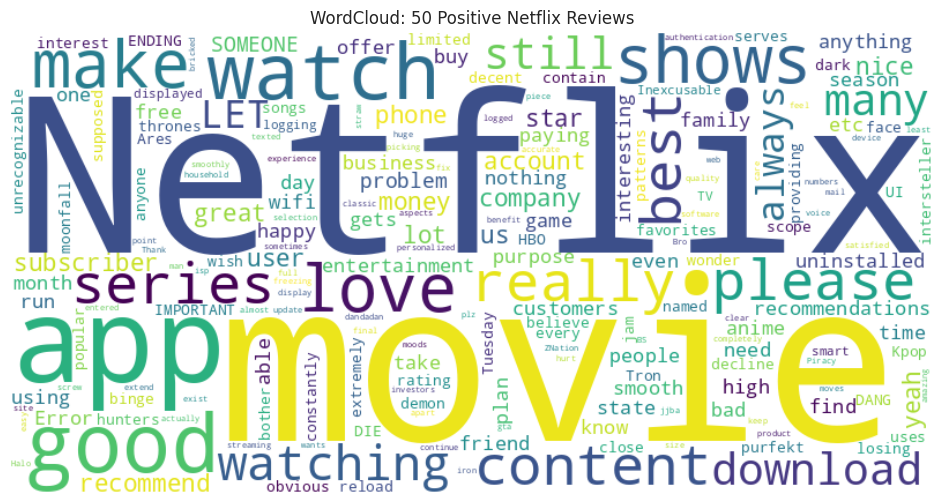

In [93]:
# Generate cloud against positive sampling
text_pos = " ".join(df_positive['content'].astype(str))
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text_pos)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: 50 Positive Netflix Reviews')
plt.show()

#### **Negative Review**

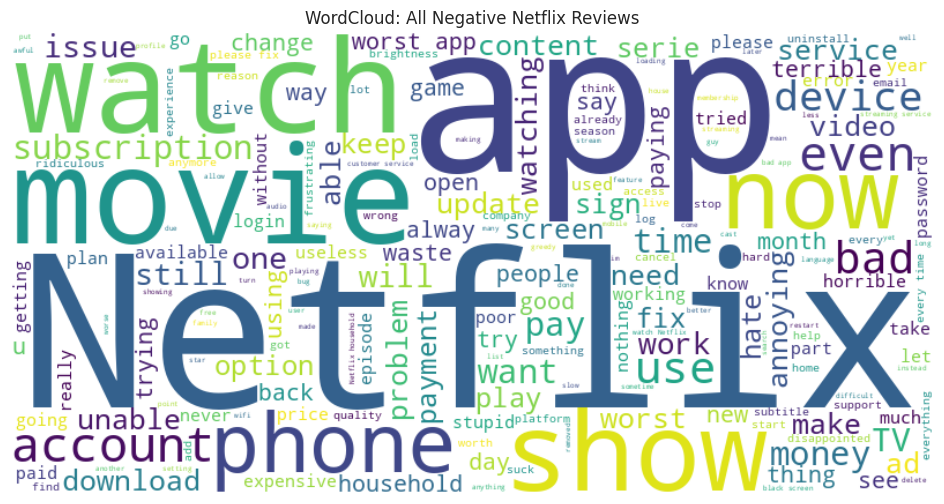

In [94]:
# Generate cloud against negative sampling
text_neg = " ".join(df_negative['content'].astype(str))
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text_neg)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: All Negative Netflix Reviews')
plt.show()

### **9. TF-IDF**


TF-IDF shape: (79714, 3000)

Top 20 terms berdasarkan skor TF-IDF rata-rata:
application    0.050591
netflix        0.039483
movie          0.035159
good           0.035147
not            0.025573
watch          0.022200
love           0.021793
cannot         0.019296
show           0.018193
best           0.018114
like           0.015836
please         0.014743
do             0.013592
great          0.013103
nice           0.012708
phone          0.012287
time           0.011984
account        0.011698
even           0.011687
am             0.011332
dtype: float64


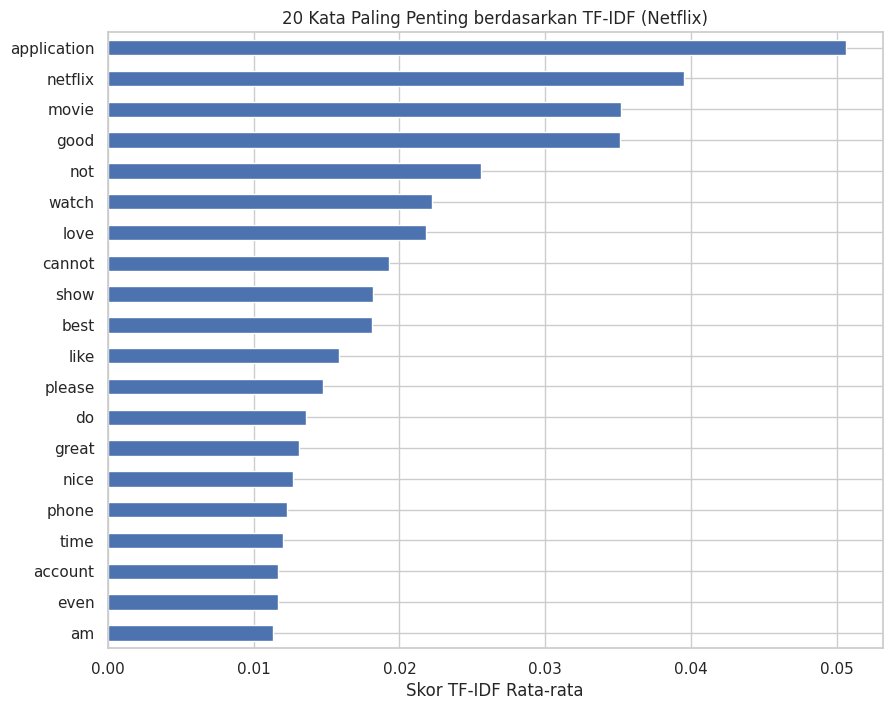


Proses selesai. Data disimpan ke netflix_processed_data.csv


In [95]:
# Membuat TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)
tfidf_features = tfidf.fit_transform(corpus).toarray()

print("TF-IDF shape:", tfidf_features.shape)

# Membuat DataFrame hasil TF-IDF
tfidf_df = pd.DataFrame(tfidf_features, columns=tfidf.get_feature_names_out())

# Hitung rata-rata skor TF-IDF tiap kata di semua dokumen
avg_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False)
print("\nTop 20 terms berdasarkan skor TF-IDF rata-rata:")
print(avg_tfidf.head(20))

# Visualisasi Kata dengan Skor TF-IDF Tertinggi
plt.figure(figsize=(10,8))
avg_tfidf.head(20).plot(kind='barh')
plt.title("20 Kata Paling Penting berdasarkan TF-IDF (Netflix)")
plt.xlabel("Skor TF-IDF Rata-rata")
plt.gca().invert_yaxis()
plt.show()

# Simpan hasil akhir
df_clean.to_csv("netflix_processed_data.csv", index=False)
print("\nProses selesai. Data disimpan ke netflix_processed_data.csv")